In [5]:
import pandas as pd

df = pd.read_csv("customer_journey.csv")
df.head()


,SessionID,UserID,Timestamp,PageType,DeviceType,Country,ReferralSource,TimeOnPage_seconds,ItemsInCart,Purchased
0,session_0,user_2223,2025-01-20 22:53:34,home,Desktop,India,Social Media,55,0,0
1,session_1,user_2192,2025-02-26 12:57:10,home,Tablet,Germany,Email,99,0,0
2,session_1,user_2192,2025-02-26 12:59:11,product_page,Tablet,Germany,Email,121,0,0
3,session_2,user_1708,2025-06-24 15:40:46,home,Mobile,India,Google,160,0,0
4,session_3,user_2976,2025-06-11 07:21:02,home,Tablet,UK,Google,113,0,0


In [6]:
df.columns
df['PageType'].value_counts()

,count
PageType,
home,5000
product_page,3987
cart,1599
checkout,1123
confirmation,1010


In [7]:
steps = ['home', 'product_page', 'cart', 'checkout', 'confirmation']

funnel = df.groupby('PageType')['UserID'].nunique().reindex(steps)

funnel

,UserID
PageType,
home,1872
product_page,1763
cart,1084
checkout,855
confirmation,792


In [8]:
drop_off = funnel.pct_change() * 100
drop_off

,UserID
PageType,
home,NaN
product_page,-5.822650
cart,-38.513897
checkout,-21.125461
confirmation,-7.368421


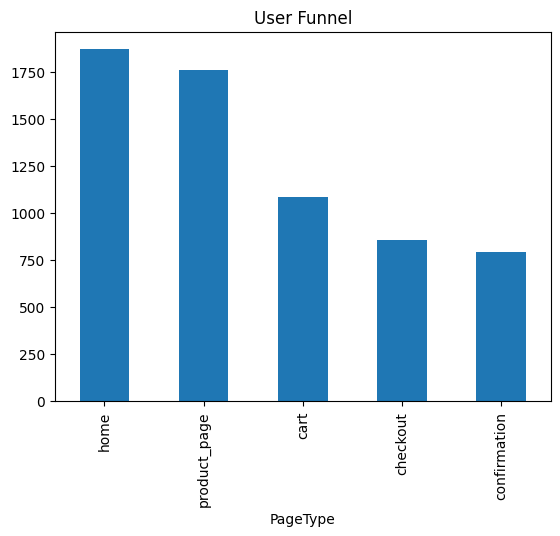

In [9]:
import matplotlib.pyplot as plt

funnel.plot(kind='bar')
plt.title("User Funnel")
plt.show()

In [10]:
df.groupby(['DeviceType', 'PageType'])['UserID'].nunique().unstack()

PageType,cart,checkout,confirmation,home,product_page
DeviceType,,,,,
Desktop,456,350,315,1161,992
Mobile,452,337,312,1127,989
Tablet,460,338,313,1137,975


In [11]:
df.groupby(['ReferralSource', 'PageType'])['UserID'].nunique().unstack()

PageType,cart,checkout,confirmation,home,product_page
ReferralSource,,,,,
Direct,354,250,230,925,780
Email,360,255,230,940,805
Google,389,288,262,969,809
Social Media,346,252,225,915,780


In [ ]:
# KEY INSIGHTS

# 1. Largest drop (~60%) occurs between product page and cart
# → Users are not convinced to add items

# 2. Checkout stage has high completion (~90%)
# → Strong purchase intent once users reach checkout

# 3. Device analysis shows similar behavior across all devices
# → Issue is not device-specific

# 4. Google traffic converts best, Social Media worst
# → Traffic quality impacts conversion

In [ ]:
# RECOMMENDATIONS

# 1. Improve product page:
#    - Add reviews, ratings, better images

# 2. Pricing transparency:
#    - Show final cost early (avoid surprises)

# 3. Improve social media campaigns:
#    - Better targeting and messaging

# 4. Increase Google marketing investment:
#    - Higher conversion source

# 5. Add urgency:
#    - Limited stock / time offers